In [1]:
import numpy as np
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import boxcox

In [2]:
def graph_objects(xs, ys, cs):
    fig = go.Figure(data=[go.Scatter3d(x=xs, y=ys, z=cs,
                                       mode='markers', 
                                       marker=dict(
                                       size=12,
                                       color=cs,                # set color to an array/list of desired values
                                       colorscale='Viridis',   # choose a colorscale
                                       opacity=1.0
        ))])
    fig.update_layout(scene = dict(
                        xaxis_title='x',
                        yaxis_title='y',
                        zaxis_title='scaling constant'),
                        margin=dict(r=20, b=10, l=10, t=10))
    fig.show()

In [3]:
parameter_pairs = []
for a in np.linspace(1.5,8):
    for b in np.linspace(1.5,8):
        parameter_pairs.append((a,b))

def beta_skew(a,b):
    return (2*(b-a)*np.sqrt(a+b+1))/((a+b+2)*np.sqrt(a*b))

In [ ]:
parameter_cs = []
for pair in parameter_pairs:
    sample_avg_cs = []
    for sample_params in np.array([200,500,1000,5000]):
        cs = []
        for seed in np.array([2,34,567,2021,0]):
            rng = np.random.default_rng(seed=seed)
            sample = rng.beta(pair[0],pair[1],sample_params) 
            sample = sample[sample >= np.percentile(sample, 66.7)]
            c = (1-np.max(sample)) / np.std(sample,ddof=1)
            cs.append(c)
        sample_avg_cs.append(np.average(cs))
    parameter_cs.append(np.average(sample_avg_cs))

In [ ]:
#option 2: depend c values on sample size and skewness rather than alpha and beta
#TODO: This is fucked lol
parameter_cs = []
sample_params = []
for sample_size in np.arange(200,2000,200):
    sample_avg_cs = []
    for pair in parameter_pairs:
        cs = []
        skew = []
        for seed in np.array([2,34,11,567,99,101,1000,2021]):
            rng = np.random.default_rng(seed=seed)
            sample = rng.beta(pair[0],pair[1],sample_size)
            sample = sample[sample >= np.percentile(sample, 75)]
            cs.append((1-np.max(sample)) / np.std(sample,ddof=1))
            skew.append(beta_skew(pair[0],pair[1]))
        parameter_cs.append(np.average(cs))
        sample_params.append((sample_size,np.average(skew)))    

In [ ]:
points = {}
for size in [100,200,500,1000,2000,5000]:
    for pair in parameter_pairs:
        cs = []
        skews = []
        for seed in np.array([2,34,11,567,99,101,1000,2021]):
            rng = np.random.default_rng(seed=seed)
            sample = rng.beta(pair[0],pair[1],size)
            sample = sample[sample >= np.percentile(sample, 75)]
            c = (1-np.max(sample)) / np.std(sample,ddof=1)
            cs.append(c)
            skew = beta_skew(pair[0],pair[1])
            skews.append(skew)
        if np.average(skews) not in points.keys():
            points[np.average(skews)] = [np.average(cs)]
        else: points[np.average(skews)].append(np.average(cs))

points2 = {}
for k in points.keys():
    points2[k] = np.average(points[k])
print(points2)

In [ ]:
import seaborn as sns
sns.scatterplot(x=points2.keys(),y=points2.values())

In [ ]:
points = {}
for size in np.arange(200,5000,200):
    for pair in parameter_pairs:
        cs = []
        skews = []
        for seed in np.array([2,34,11,567,99,101,1000,2021]):
            rng = np.random.default_rng(seed=seed)
            sample = rng.beta(pair[0],pair[1],size)
            sample = sample[sample >= np.percentile(sample, 75)]
            c = (1-np.max(sample)) / np.std(sample,ddof=1) #generate c for specified skew (ie. alpha & beta), sample size and sample scheme
            cs.append(c)
            skew = beta_skew(pair[0],pair[1]) #calculate skew
            skews.append(skew)
        if np.average(skews) not in points.keys(): #group all c that has the same skew and sample size together
            points[(np.average(skews),size)] = [np.average(cs)]
        else: points[(np.average(skews),size)].append(np.average(cs))

sizes = []
skews = []
cs = []
for k in points.keys():
    sizes.append(k[1])
    skews.append(k[0])
    cs.append(np.average(points[k])) #calculate sample average of c for particular skew and sample size

In [ ]:
graph_objects(sizes,skews,cs)

In [ ]:
points = {}
for size in np.arange(200,5000,200):
    for pair in parameter_pairs:
        cs = []
        skews = []
        for seed in np.array([2,34,11,567,99,101,1000,2021]):
            rng = np.random.default_rng(seed=seed)
            sample = rng.beta(pair[0],pair[1],size)
            sample = sample[sample >= np.percentile(sample, 75)]
            c = np.exp(-1*(1-np.max(sample)) / np.std(sample,ddof=1))
            cs.append(c)
            skew = beta_skew(pair[0],pair[1])
            skews.append(skew)
        if np.average(skews) not in points.keys():
            points[(np.average(skews),size)] = [np.average(cs)]
        else: points[(np.average(skews),size)].append(np.average(cs))

sizes = []
skews = []
cs = []
for k in points.keys():
    sizes.append(k[1])
    skews.append(k[0])
    cs.append(np.average(points[k]))

In [ ]:
graph_objects(sizes,skews,cs) #suggestion 2 does not seem to produce workable function?
#Use boxcox to make distribution symmetric -> c only depends on sample size n (easier to graph)

In [11]:
#option 1: make c a function of Y_n - Y_n-1
#By Y_(n-1) he means the second largest point
parameter_cs = []
avg_sds = []
for pair in parameter_pairs:
    cs = []
    sds = []
    for seed in [2,34,11,567,99,101,1000,2021]:
        rng = np.random.default_rng(seed=seed)
        sample = rng.beta(pair[0],pair[1],1000)
        sample = -np.sort(-sample)
        sd = np.std(sample)
        c = ((1-sample[0])/((sample[0]-sample[1])))
        cs.append(c)
        sds.append(sd)
    parameter_cs.append(np.average(cs))
    avg_sds.append(np.average(sds))

parameter_cs = np.asarray(parameter_cs)
avg_sds = np.asarray(avg_sds)
        

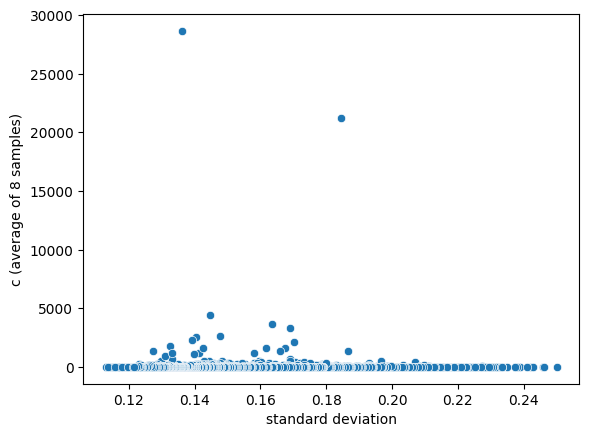

In [12]:
ax = sns.scatterplot(x=avg_sds, y=parameter_cs)
ax.set(xlabel='standard deviation', ylabel='c (average of 8 samples)')
plt.show()

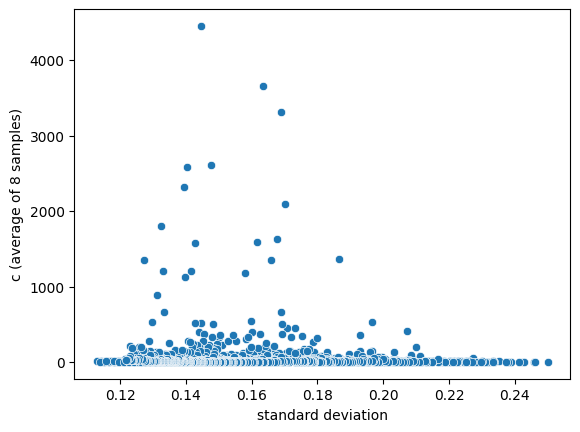

In [13]:
no_out_sds = avg_sds[np.array(parameter_cs) < 5000.00]
no_out_cs = parameter_cs[np.array(parameter_cs) < 5000.00]

ax = sns.scatterplot(x=no_out_sds, y=no_out_cs)
ax.set(xlabel='standard deviation', ylabel='c (average of 8 samples)')
plt.show()

In [ ]:
#Also perform Box-Cox transformation on the endpoints (1)
parameter_cs = []
avg_sds = []
for pair in parameter_pairs:
    cs = []
    sds = []
    for seed in [2,34,11,567,99,101,1000,2021]:
        rng = np.random.default_rng(seed=seed)
        boxcox_obj = boxcox(rng.beta(pair[0],pair[1],1000))
        sample = boxcox_obj[0]
        sample = -np.sort(-sample)
        sd = np.std(sample)
        c = (sample[0])/((sample[0] - sample[1]+0.0001)*sd) #If we apply the box-cox transformation the endpoint will be 0 regardless of lambda value
        cs.append(c)
        sds.append(sd)
    parameter_cs.append(np.average(cs))
    avg_sds.append(np.average(sds))

In [ ]:
ax = sns.scatterplot(x=np.delete(avg_sds,np.argmax(parameter_cs)), y=np.delete(parameter_cs,np.argmax(parameter_cs)))
ax.set(xlabel='standard deviation', ylabel='c (average of 8 samples)')
plt.show()